# Gibbs MCMC Results Summary

In [ ]:
import importlib
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.simplefilter('ignore')
project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / 'src'))

from func_data_build import build_dataset
from func_gibbs.gibbs_notebook_utils import display_hmc_results, display_hmc_posterior_prior
from func_gibbs.gibbs_wrappers import draws_to_idata
import func_gibbs.gibbs_wrappers as gibbs_module
from func_gibbs.gibbs_wrappers import run_ces, run_hsa_dynamic, run_hsa_steady

In [21]:
## 0. load data

data_dir = project_root / "data"
data = build_dataset(data_dir)
data["DATE"] = pd.to_datetime(data.index)

## 1. model specifications
inflation_specs = {
    "ppi": {
        "pi": "pi_ppi",
        "pi_prev": "pi_ppi_prev",
        "pi_expect": "Epi_spf_gdp",
    },
    "cpi": {
        "pi": "pi_cpi",
        "pi_prev": "pi_cpi_prev",
        "pi_expect": "Epi_spf_cpi",
    },
}

model_grid = [
    {
        "model_id": "S1_U_G",
        "set": 1,
        "inflation": "ppi",
        "gap": "unemp_gap",
        "N": "N_Gustavo",
    },
    {
        "model_id": "S1_U_T",
        "set": 1,
        "inflation": "ppi",
        "gap": "unemp_gap",
        "N": "N_TNIC",
    },
    {
        "model_id": "S1_Y_G",
        "set": 1,
        "inflation": "ppi",
        "gap": "output_gap_BN",
        "N": "N_Gustavo",
    },
    {
        "model_id": "S1_Y_T",
        "set": 1,
        "inflation": "ppi",
        "gap": "output_gap_BN",
        "N": "N_TNIC",
    },
    {
        "model_id": "S2_U_G",
        "set": 2,
        "inflation": "cpi",
        "gap": "unemp_gap",
        "N": "N_Gustavo",
    },
    {
        "model_id": "S2_U_T",
        "set": 2,
        "inflation": "cpi",
        "gap": "unemp_gap",
        "N": "N_TNIC",
    },
    {
        "model_id": "S2_Y_G",
        "set": 2,
        "inflation": "cpi",
        "gap": "output_gap_BN",
        "N": "N_Gustavo",
    },
    {
        "model_id": "S2_Y_T",
        "set": 2,
        "inflation": "cpi",
        "gap": "output_gap_BN",
        "N": "N_TNIC",
    },
]

## 3. Summary of posterior distribution

,model_id,set,inflation,gap,N,start,end,T
0,S1_U_G,1,ppi,unemp_gap,N_Gustavo,1974-03-31 23:59:59.999999999,2012-12-31 23:59:59.999999999,155
1,S1_U_T,1,ppi,unemp_gap,N_TNIC,1988-03-31 23:59:59.999999999,2022-12-31 23:59:59.999999999,140
2,S1_Y_G,1,ppi,output_gap_BN,N_Gustavo,1974-03-31 23:59:59.999999999,2012-12-31 23:59:59.999999999,155
3,S1_Y_T,1,ppi,output_gap_BN,N_TNIC,1988-03-31 23:59:59.999999999,2022-12-31 23:59:59.999999999,140
4,S2_U_G,2,cpi,unemp_gap,N_Gustavo,1981-09-30 23:59:59.999999999,2012-12-31 23:59:59.999999999,126
5,S2_U_T,2,cpi,unemp_gap,N_TNIC,1988-03-31 23:59:59.999999999,2022-12-31 23:59:59.999999999,140
6,S2_Y_G,2,cpi,output_gap_BN,N_Gustavo,1981-09-30 23:59:59.999999999,2012-12-31 23:59:59.999999999,126
7,S2_Y_T,2,cpi,output_gap_BN,N_TNIC,1988-03-31 23:59:59.999999999,2022-12-31 23:59:59.999999999,140


,parameter,prior_mean,prior_sd
0,alpha,0.5,0.2
1,kappa,0.1,0.2
2,phi_1,0.7,0.2
3,rho,0.0,0.5


Running S1_U_G_CES_corr | sample: 1974-03-31 23:59:59.999999999 to 2012-12-31 23:59:59.999999999 | T = 155
Running S1_U_G_CES_uncorr | sample: 1974-03-31 23:59:59.999999999 to 2012-12-31 23:59:59.999999999 | T = 155
Running S1_U_T_CES_corr | sample: 1988-03-31 23:59:59.999999999 to 2022-12-31 23:59:59.999999999 | T = 140
Running S1_U_T_CES_uncorr | sample: 1988-03-31 23:59:59.999999999 to 2022-12-31 23:59:59.999999999 | T = 140
Running S1_Y_G_CES_corr | sample: 1974-03-31 23:59:59.999999999 to 2012-12-31 23:59:59.999999999 | T = 155
Running S1_Y_G_CES_uncorr | sample: 1974-03-31 23:59:59.999999999 to 2012-12-31 23:59:59.999999999 | T = 155
Running S1_Y_T_CES_corr | sample: 1988-03-31 23:59:59.999999999 to 2022-12-31 23:59:59.999999999 | T = 140
Running S1_Y_T_CES_uncorr | sample: 1988-03-31 23:59:59.999999999 to 2022-12-31 23:59:59.999999999 | T = 140
Running S2_U_G_CES_corr | sample: 1981-09-30 23:59:59.999999999 to 2012-12-31 23:59:59.999999999 | T = 126
Running S2_U_G_CES_uncorr | s

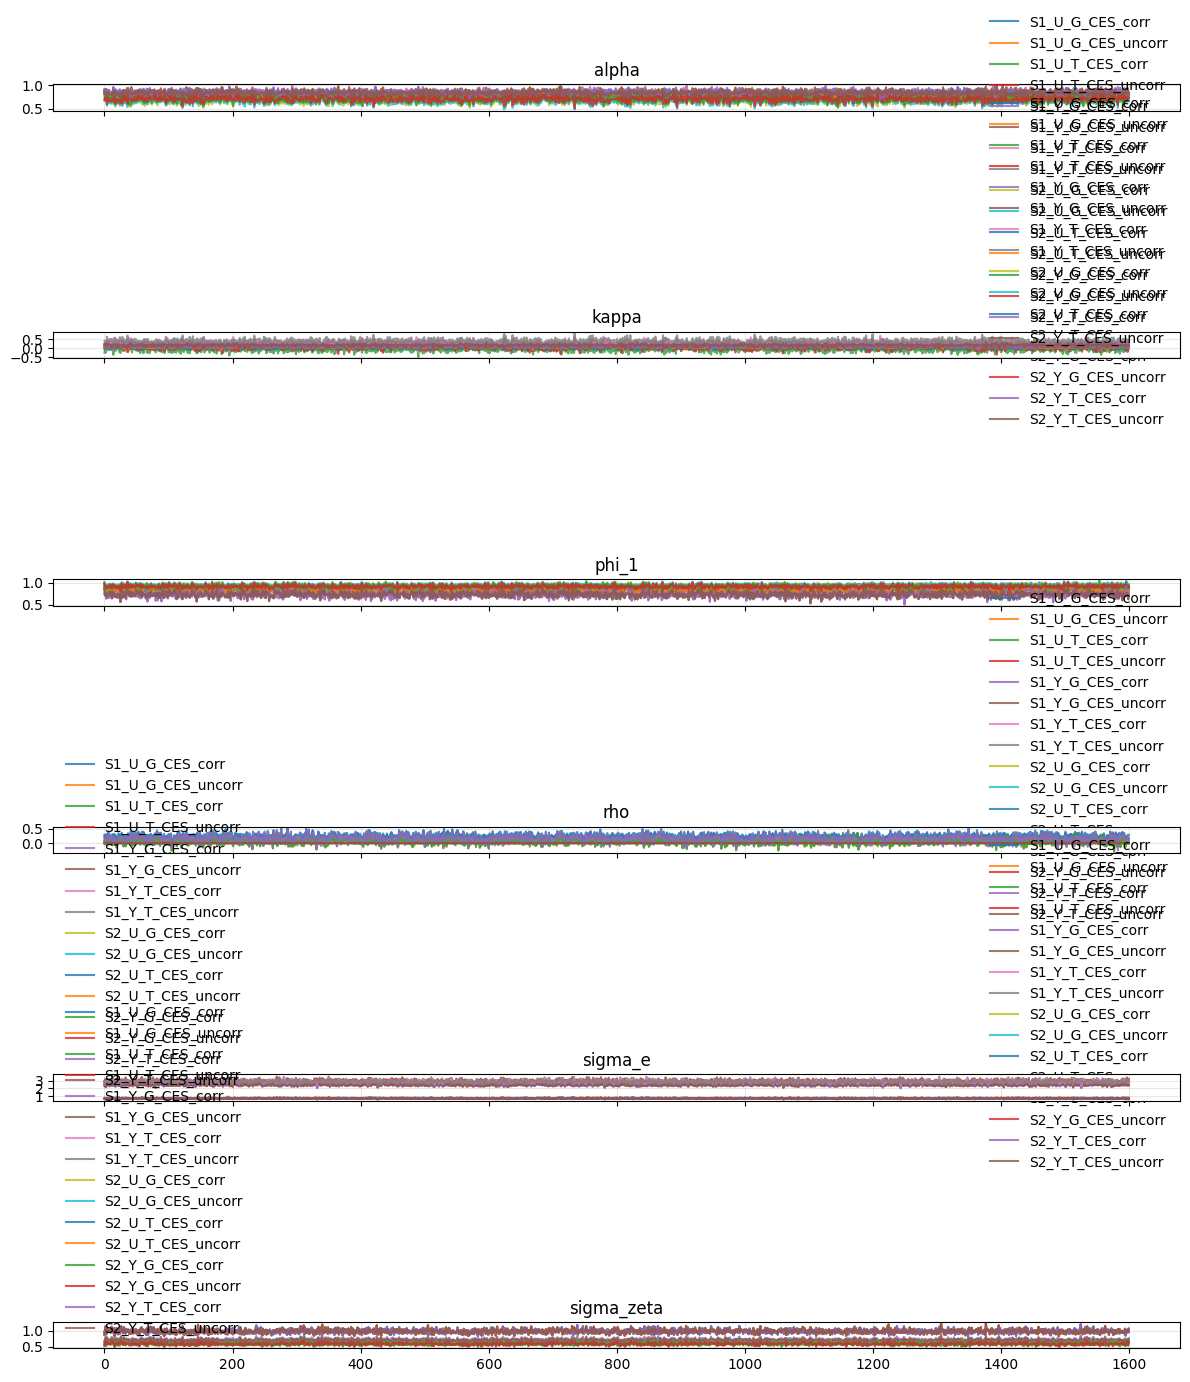

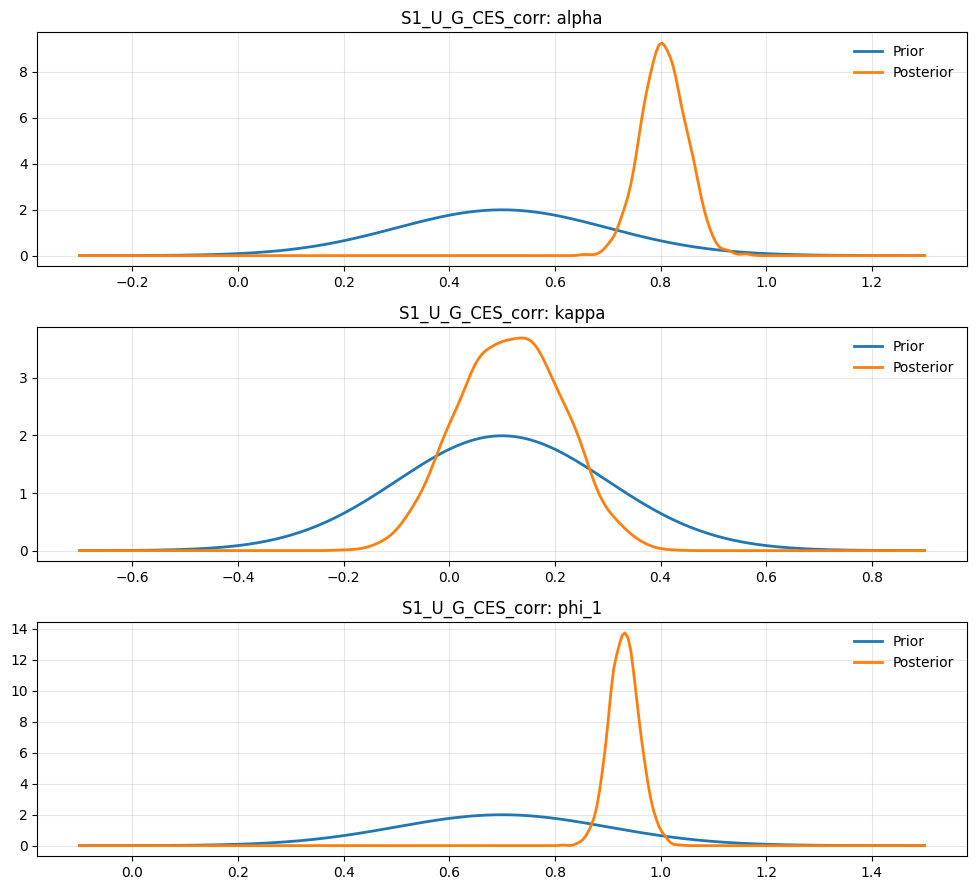

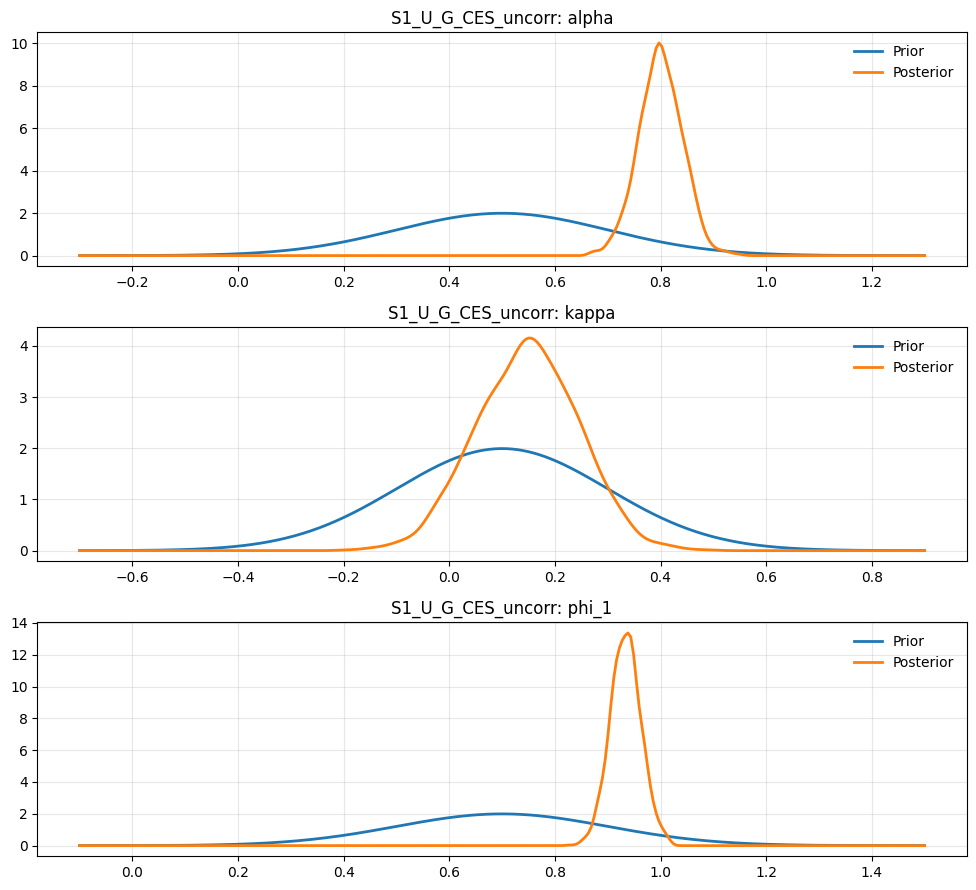

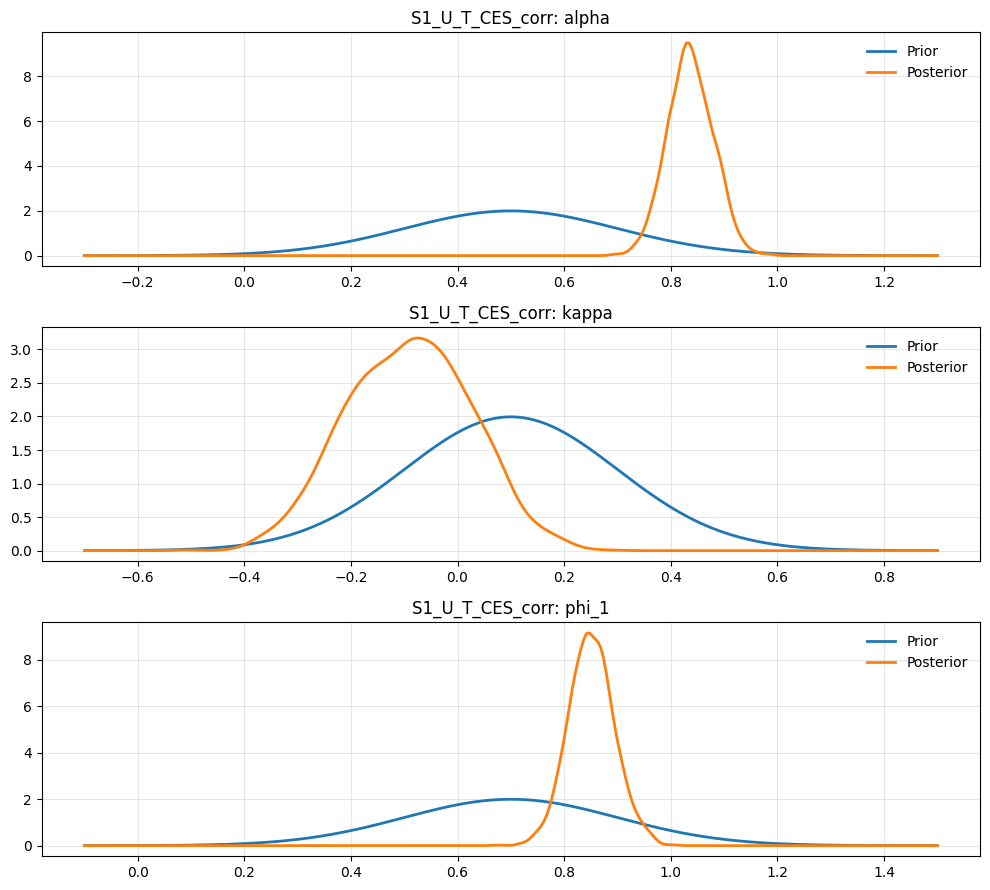

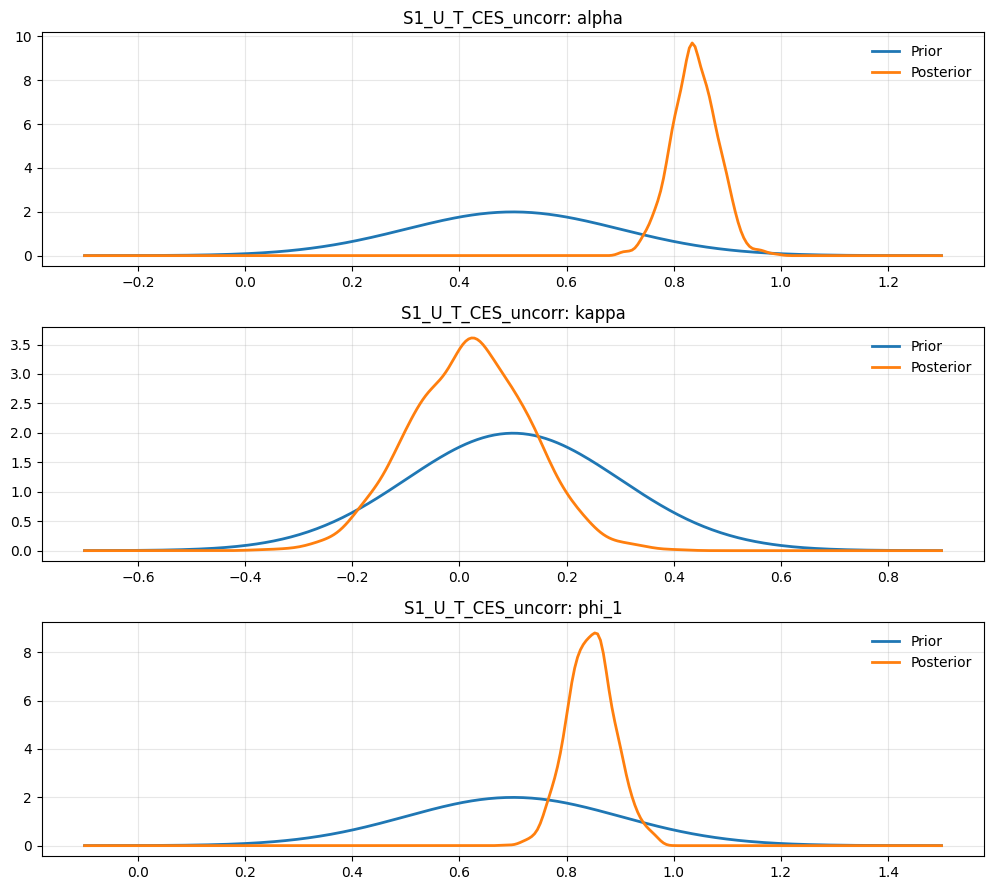

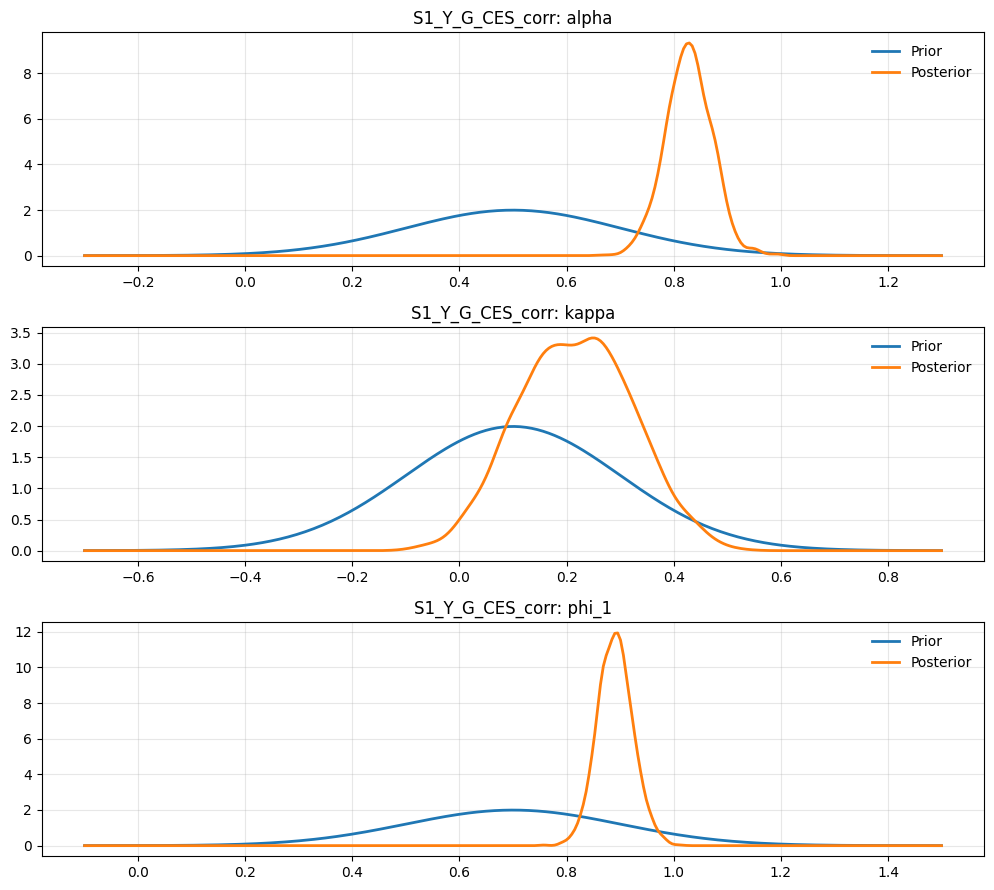

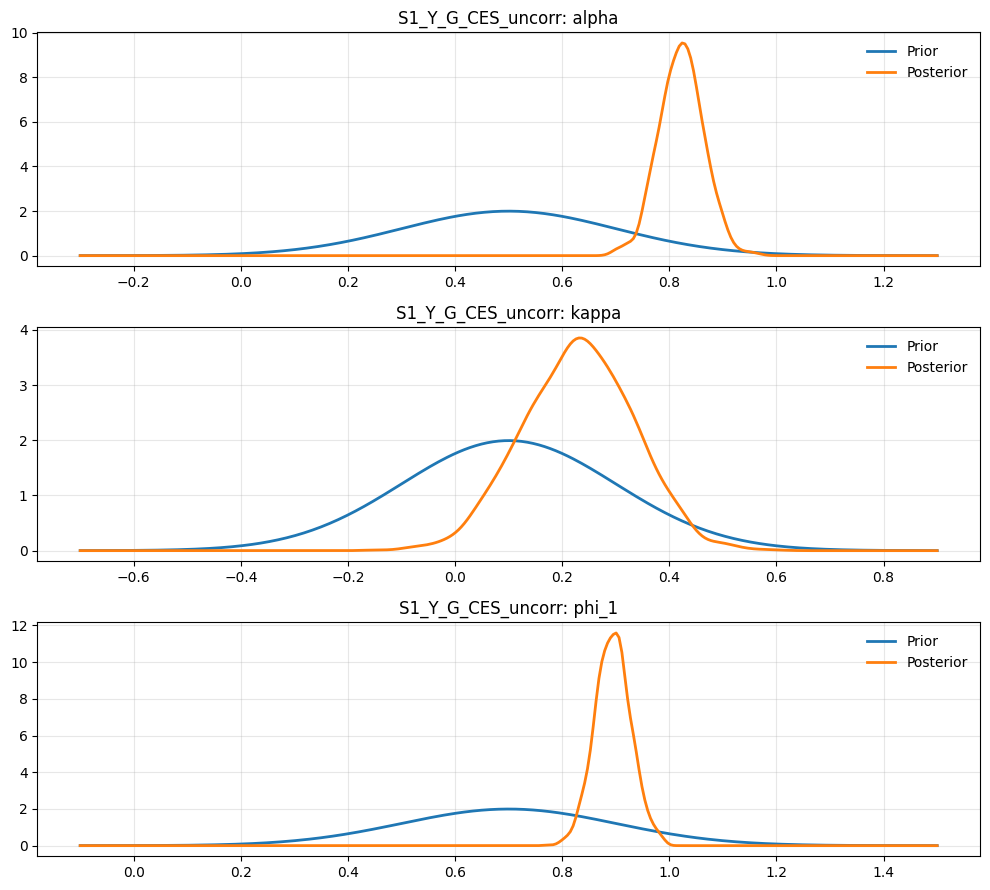

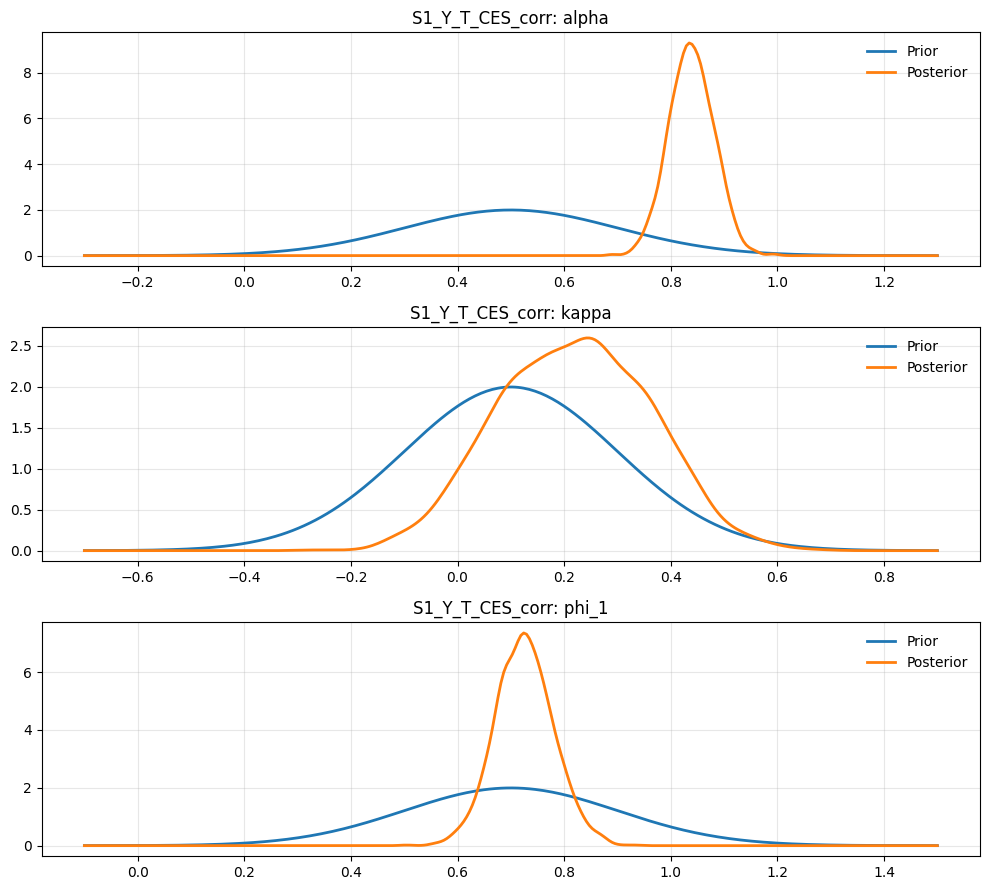

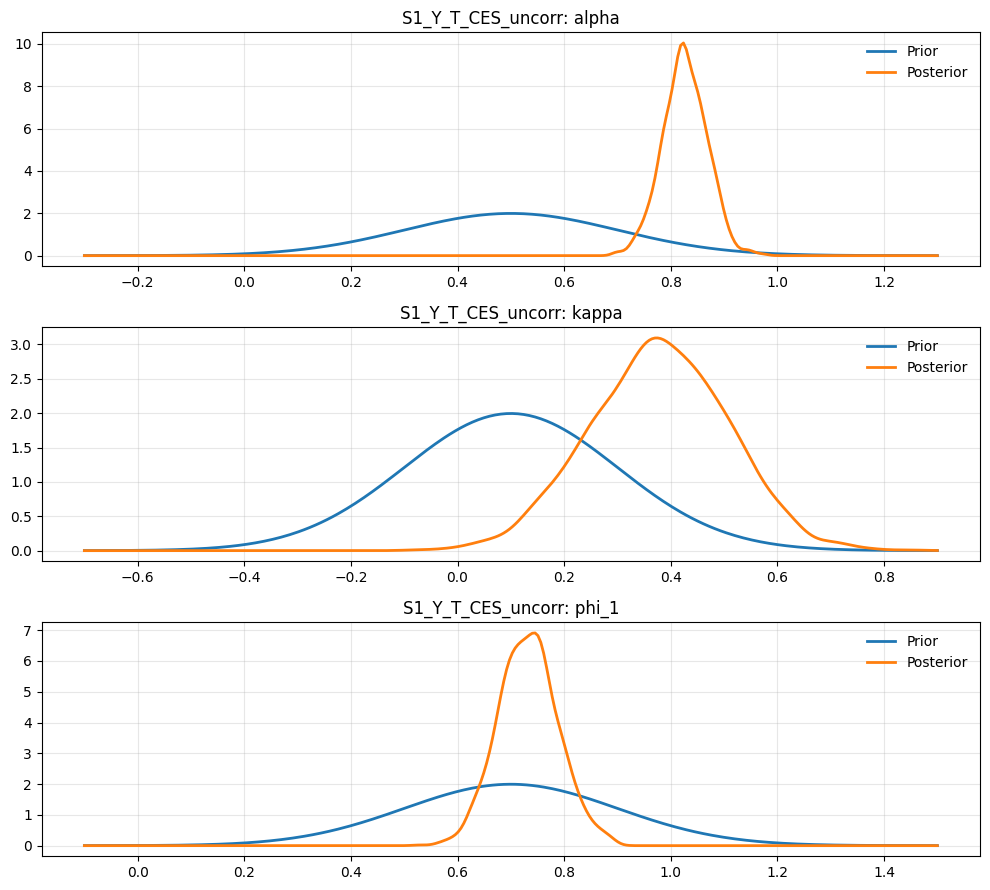

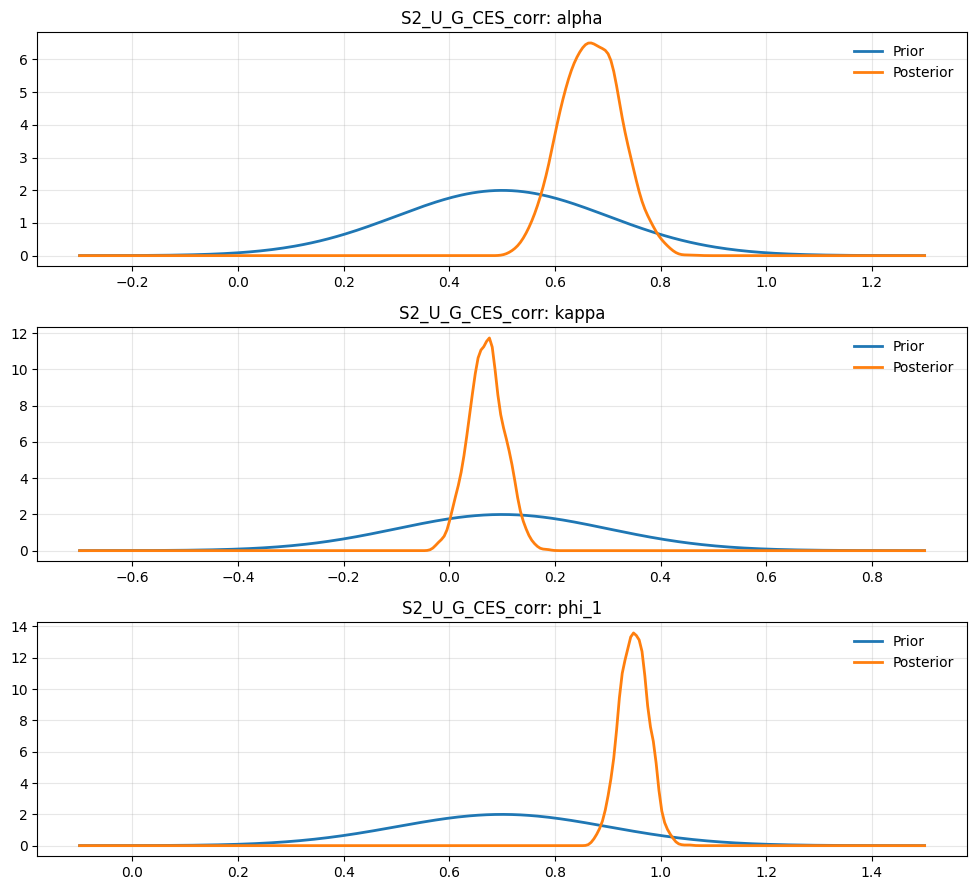

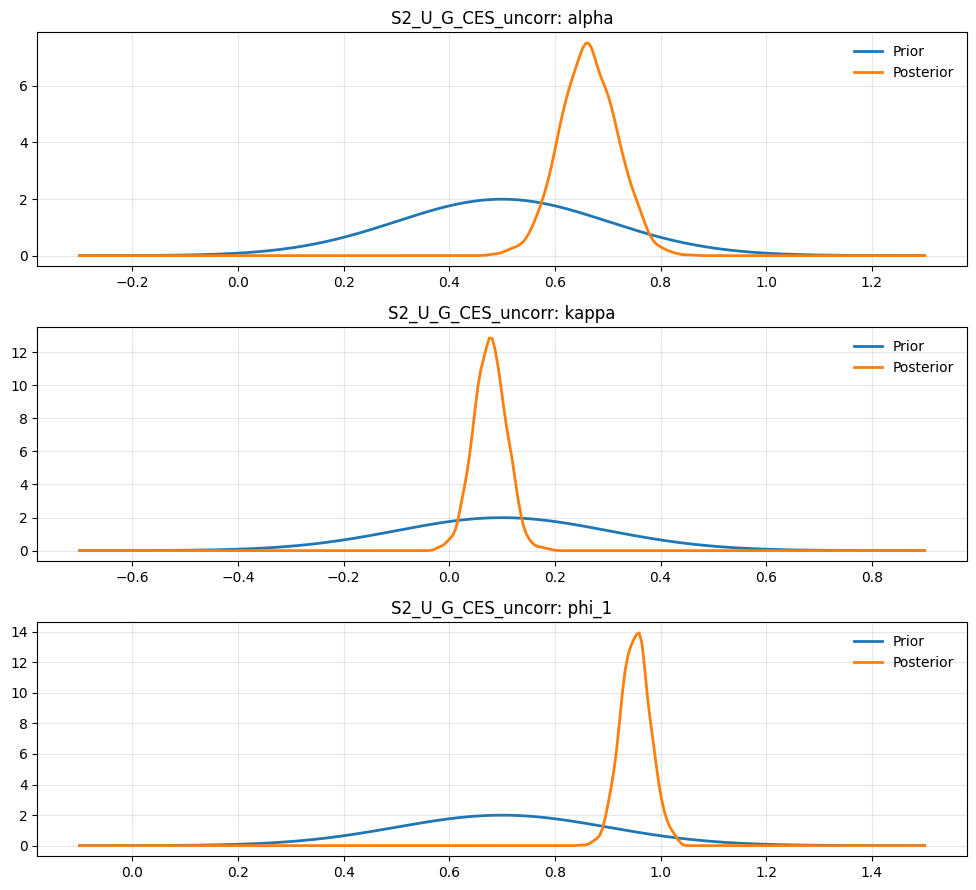

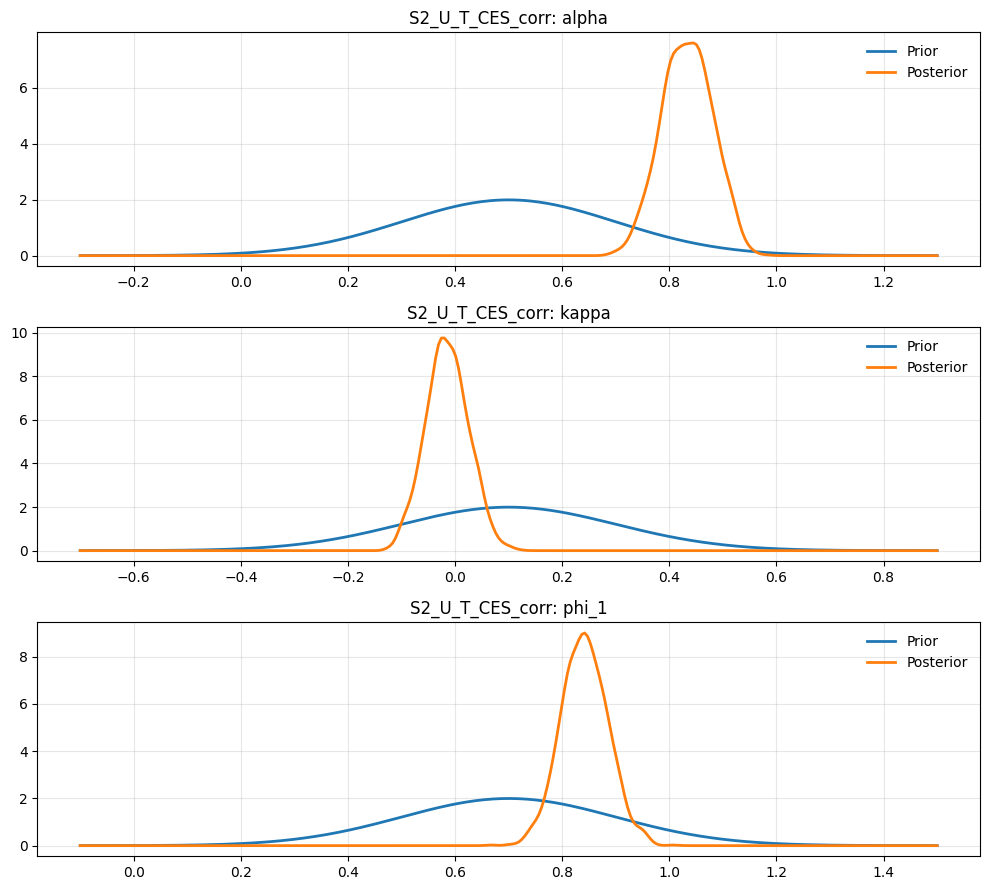

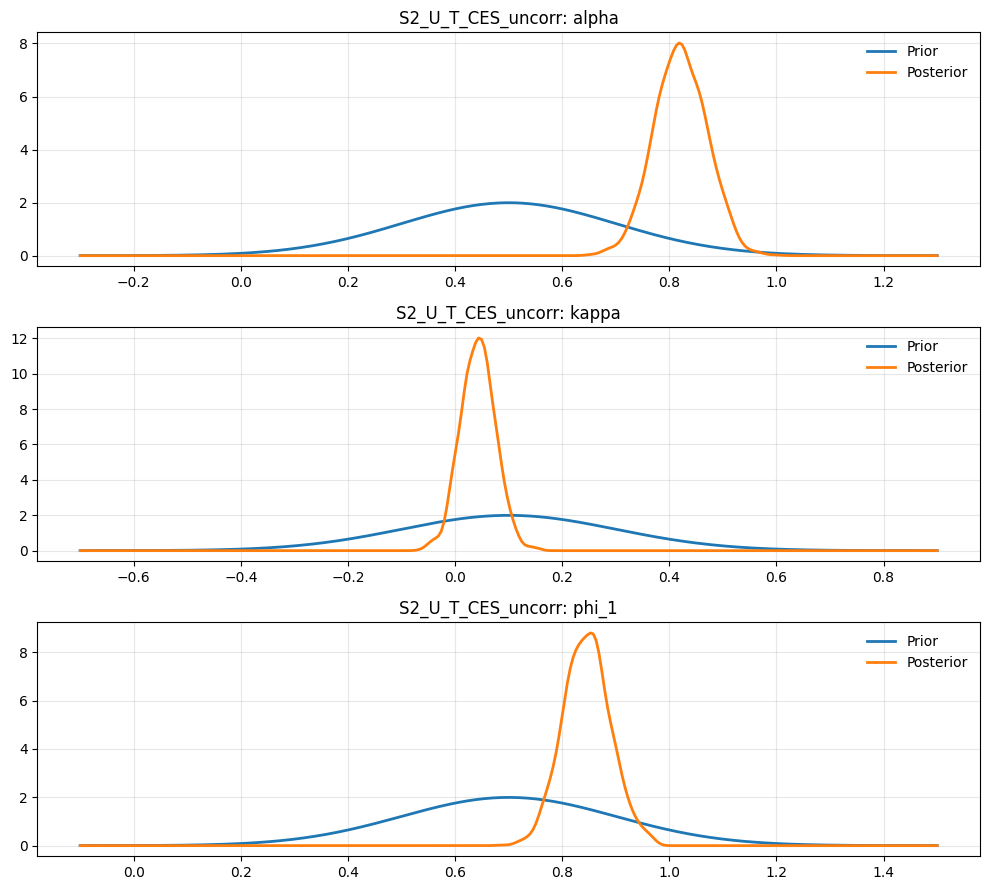

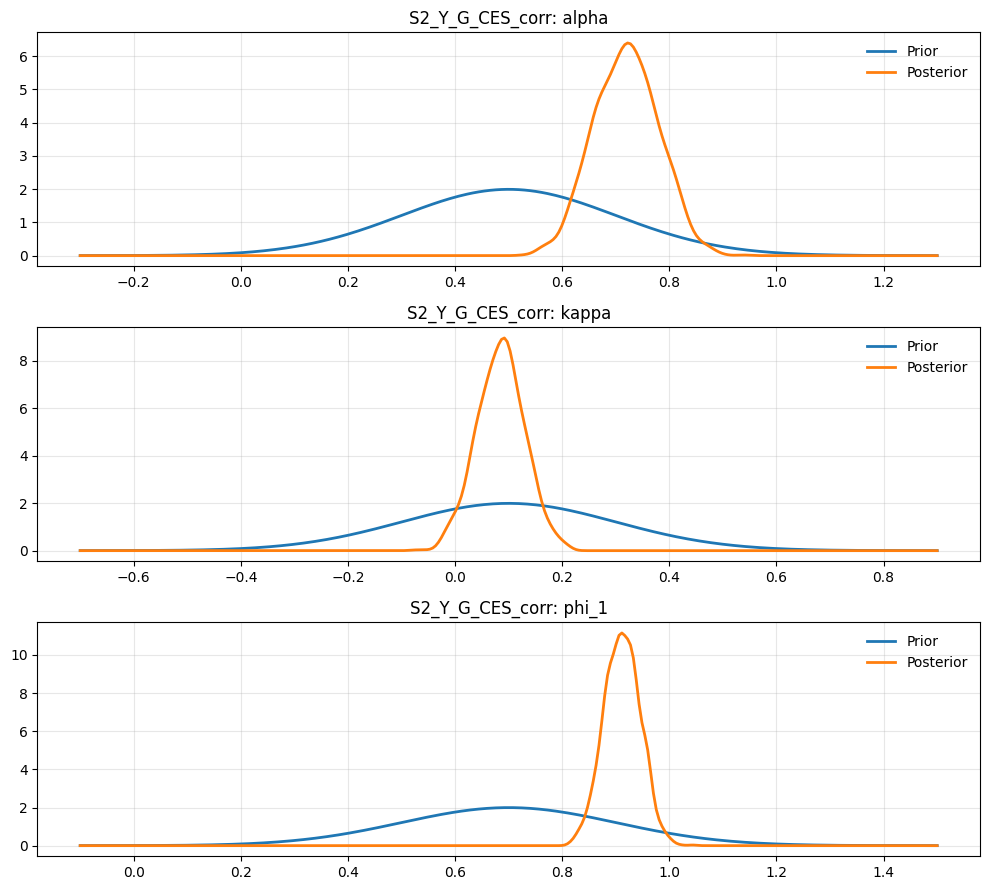

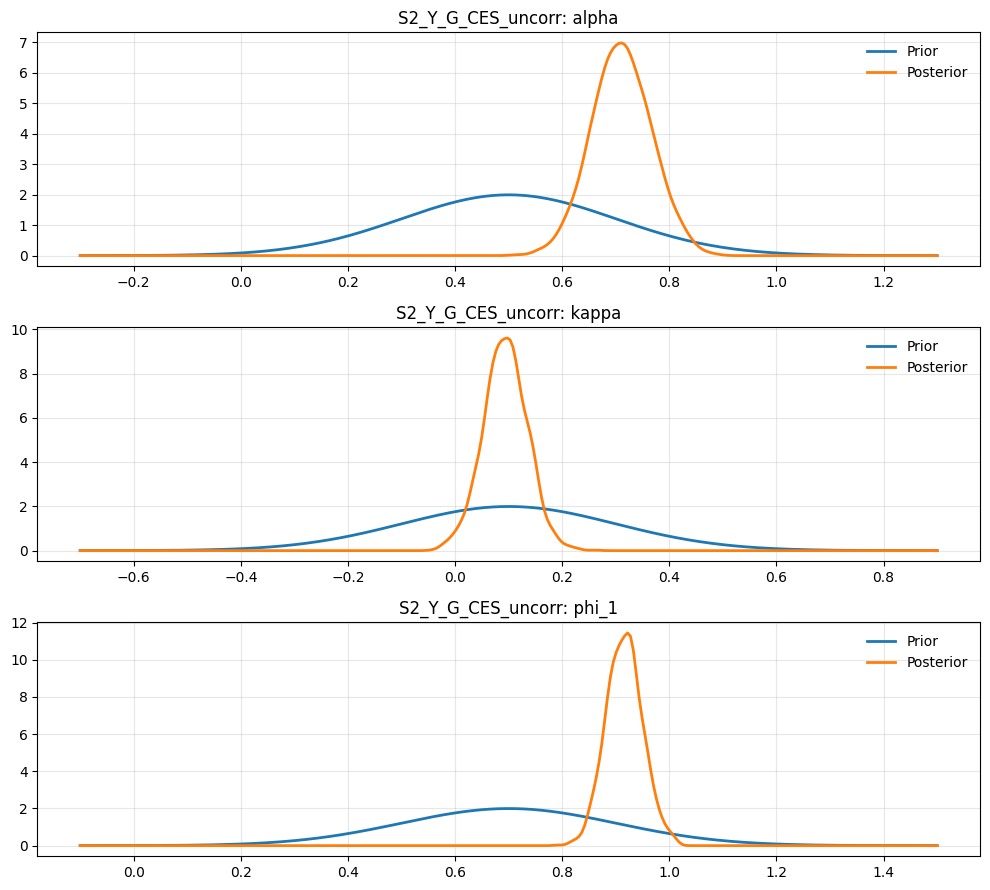

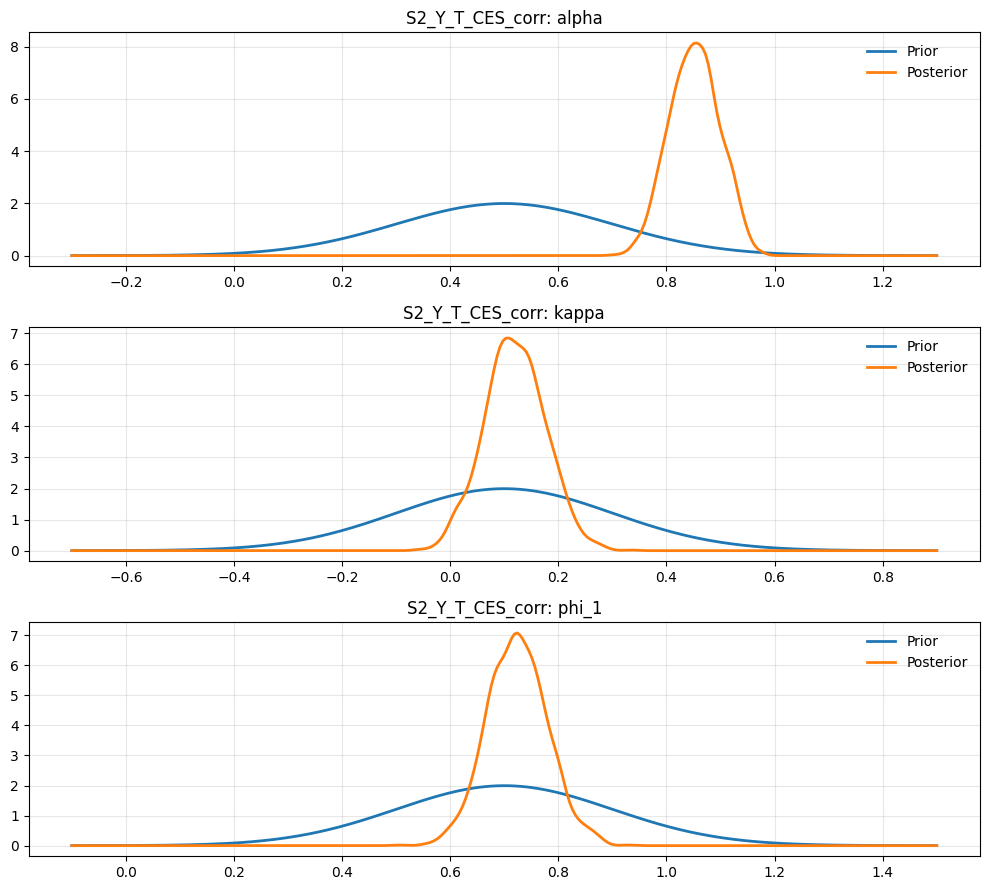

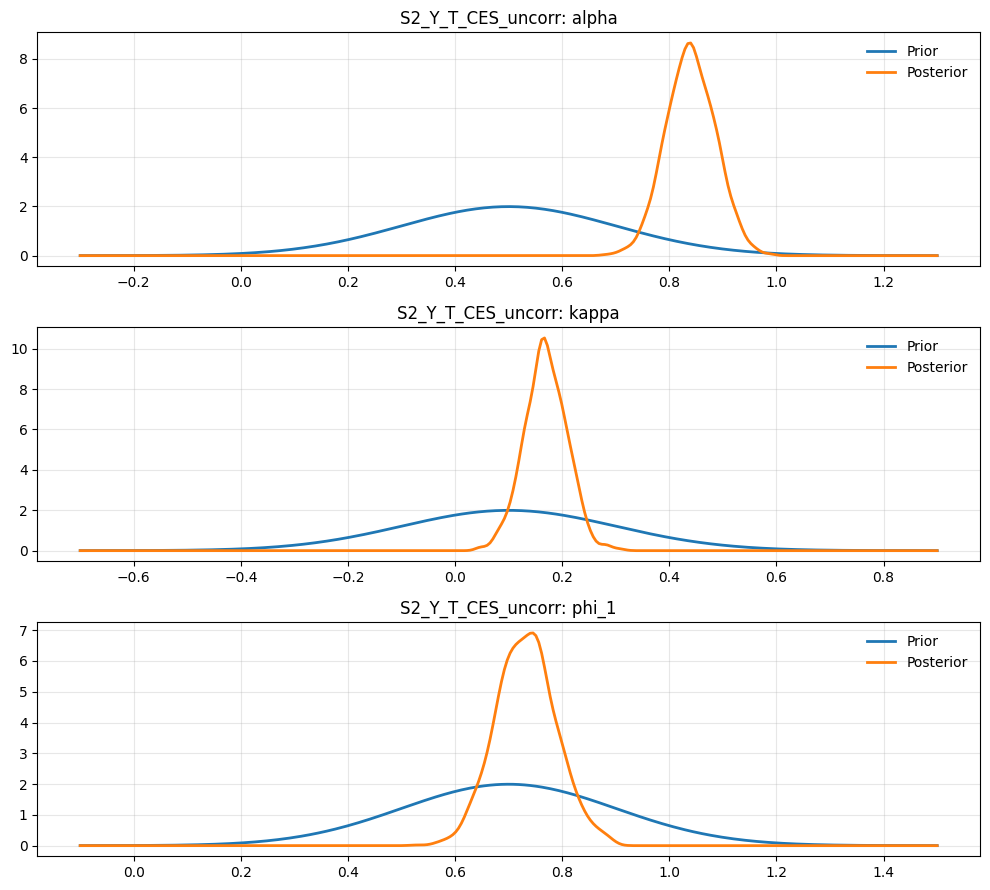

In [22]:
## 2. make model-specific maximum available sample
def make_model_sample(data, spec, inflation_specs, include_N=True):
    infl = inflation_specs[spec["inflation"]]
    gap = spec["gap"]

    required_cols = [
        infl["pi"],
        infl["pi_prev"],
        infl["pi_expect"],
        gap,
        f"{gap}_prev",
    ]

    if include_N:
        required_cols.append(spec["N"])

    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise KeyError(f"Missing columns for {spec['model_id']}: {missing_cols}")

    sample = (
        data[required_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    if sample.empty:
        raise ValueError(f"No valid sample for {spec['model_id']}")

    return sample


## 4. check sample periods

sample_info = []

for spec in model_grid:
    sample = make_model_sample(
        data=data,
        spec=spec,
        inflation_specs=inflation_specs,
        include_N=True,
    )

    sample_info.append({
        "model_id": spec["model_id"],
        "set": spec["set"],
        "inflation": spec["inflation"],
        "gap": spec["gap"],
        "N": spec["N"],
        "start": sample.index.min(),
        "end": sample.index.max(),
        "T": len(sample),
    })

sample_info_df = pd.DataFrame(sample_info)
display(sample_info_df)


## 5. prior distributions and MCMC parameters

seed = 0
n_iter = 12000
burn = 4000
thin = 5

prior_specs = {
    "alpha": (0.5, 0.2),
    "kappa": (0.1, 0.2),
    "phi_1": (0.7, 0.2),
    "rho": (0.0, 0.5),
}

display(pd.DataFrame([
    {"parameter": key, "prior_mean": value[0], "prior_sd": value[1]}
    for key, value in prior_specs.items()
]))


## 6. Gibbs MCMC: CES models

gibbs_module = importlib.reload(gibbs_module)
run_ces = gibbs_module.run_ces
draws_to_idata = gibbs_module.draws_to_idata

dict_draws = {}
dict_idata = {}

for spec in model_grid:
    sample = make_model_sample(
        data=data,
        spec=spec,
        inflation_specs=inflation_specs,
        include_N=True,
    )

    infl = inflation_specs[spec["inflation"]]
    gap = spec["gap"]

    pi = np.asarray(sample[infl["pi"]], dtype=float)
    pi_prev = np.asarray(sample[infl["pi_prev"]], dtype=float)
    pi_expect = np.asarray(sample[infl["pi_expect"]], dtype=float)

    x = np.asarray(sample[gap], dtype=float)
    x_prev = np.asarray(sample[f"{gap}_prev"], dtype=float)

    for orth in (False, True):
        label = "corr" if not orth else "uncorr"
        model_name = f"{spec['model_id']}_CES_{label}"

        print(
            "Running",
            model_name,
            "| sample:",
            sample.index.min(),
            "to",
            sample.index.max(),
            "| T =",
            len(sample),
        )

        draws = run_ces(
            pi=pi,
            pi_prev=pi_prev,
            pi_expect=pi_expect,
            x=x,
            x_prev=x_prev,
            prior_specs=prior_specs,
            n_iter=n_iter,
            burn=burn,
            thin=thin,
            rng=np.random.default_rng(seed),
            orth=orth,
        )

        dict_draws[model_name] = draws
        dict_idata[model_name] = draws_to_idata(draws)

list(dict_idata.keys())


## 7. posterior summary

display_hmc_results(
    dict_idata,
    prior_specs,
    models_to_show=list(dict_idata.keys()),
    params=("alpha", "kappa", "phi_1", "rho", "sigma_e", "sigma_zeta"),
    title="Posterior summary for CES models",
)


## 8. trace plots

trace_params = ["alpha", "kappa", "phi_1", "rho", "sigma_e", "sigma_zeta"]

fig, axes = plt.subplots(
    len(trace_params),
    1,
    figsize=(12, 2.5 * len(trace_params)),
    sharex=True,
)

if len(trace_params) == 1:
    axes = [axes]

for ax, param in zip(axes, trace_params):
    for model_name, draws in dict_draws.items():
        if param not in draws:
            continue
        ax.plot(draws[param], label=model_name, alpha=0.8)

    ax.set_title(param)
    ax.grid(alpha=0.3)
    ax.legend(loc="best", frameon=False)

fig.tight_layout()
plt.show()


## 9. posterior vs prior

from scipy.stats import gaussian_kde, norm

plot_params = ["alpha", "kappa", "phi_1"]

for model_name, draws in dict_draws.items():
    n_params = len(plot_params)

    fig, axes = plt.subplots(
        n_params,
        1,
        figsize=(10, 3.0 * n_params),
    )

    if n_params == 1:
        axes = [axes]

    for ax, param in zip(axes, plot_params):
        series = np.asarray(draws[param], dtype=float)
        finite = series[np.isfinite(series)]

        mu, sigma = prior_specs[param]
        grid = np.linspace(
            min(finite.min(), mu - 4 * sigma),
            max(finite.max(), mu + 4 * sigma),
            300,
        )

        ax.plot(grid, norm.pdf(grid, loc=mu, scale=sigma), label="Prior", lw=2)

        if finite.size > 1:
            try:
                kde = gaussian_kde(finite)
                ax.plot(grid, kde(grid), label="Posterior", lw=2)
            except Exception:
                ax.hist(
                    finite,
                    bins=min(20, max(5, finite.size)),
                    density=True,
                    alpha=0.35,
                    label="Posterior",
                )

        ax.set_title(f"{model_name}: {param}")
        ax.grid(alpha=0.3)
        ax.legend(frameon=False)

    fig.tight_layout()
    plt.show()